In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.Label_Transfer import CellAnnotator
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### Pre-training data using one slice

In [4]:
adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata.var_names_make_unique()
adata.obs['type']='Pre-training data'

In [5]:
sc.pp.scale(adata)
adata.obsm['feat']=adata.X

In [6]:
k=16
graph = prepare_inputs(adata, k, device)

In [7]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 48.06it/s, Epoch=199, Loss=0.9014]


In [9]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [10]:
adata.obsm['SpaLP']=embedding

In [11]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/label_shuffles/78_pretrian_model.pth")

In [12]:
adata.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/label_shuffles/Pre-training.h5ad',compression='gzip')

### Inference data using two slices

In [13]:
adata1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata1.var_names_make_unique()
adata1.obs['type']='Inference data1'

adata2=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.077.h5ad')
adata2.var_names_make_unique()
adata2.obs['type']='Inference data2'

In [14]:
sc.pp.scale(adata1)
adata1.obsm['feat']=adata1.X

sc.pp.scale(adata2)
adata2.obsm['feat']=adata2.X

In [15]:
graph1 = prepare_inputs(adata1, k=16, device=device)
graph2 = prepare_inputs(adata2, k=16, device=device)

### zero-shot inference embedding

In [16]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/label_shuffles/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata1.obsm['SpaLP']=embedding

In [17]:
in_channels = graph2.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/label_shuffles/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph2.features, graph2.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata2.obsm['SpaLP']=embedding

In [18]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/Pre-training.h5ad')

### Label shuffles

In [19]:
Pre_train_adata.obs['major_brain_region_shuffle'] = Pre_train_adata.obs['major_brain_region'].sample(frac=1, random_state=42).values

### Cosine similarity transfer labels after shuffles

In [21]:
from SpaLP.utils import transfer_labels_by_cosine

In [23]:
adata1=transfer_labels_by_cosine(pre_adata=Pre_train_adata,new_adata=adata1,label_key='major_brain_region_shuffle',embedding_key='SpaLP')
adata2=transfer_labels_by_cosine(pre_adata=Pre_train_adata,new_adata=adata2,label_key='major_brain_region_shuffle',embedding_key='SpaLP')

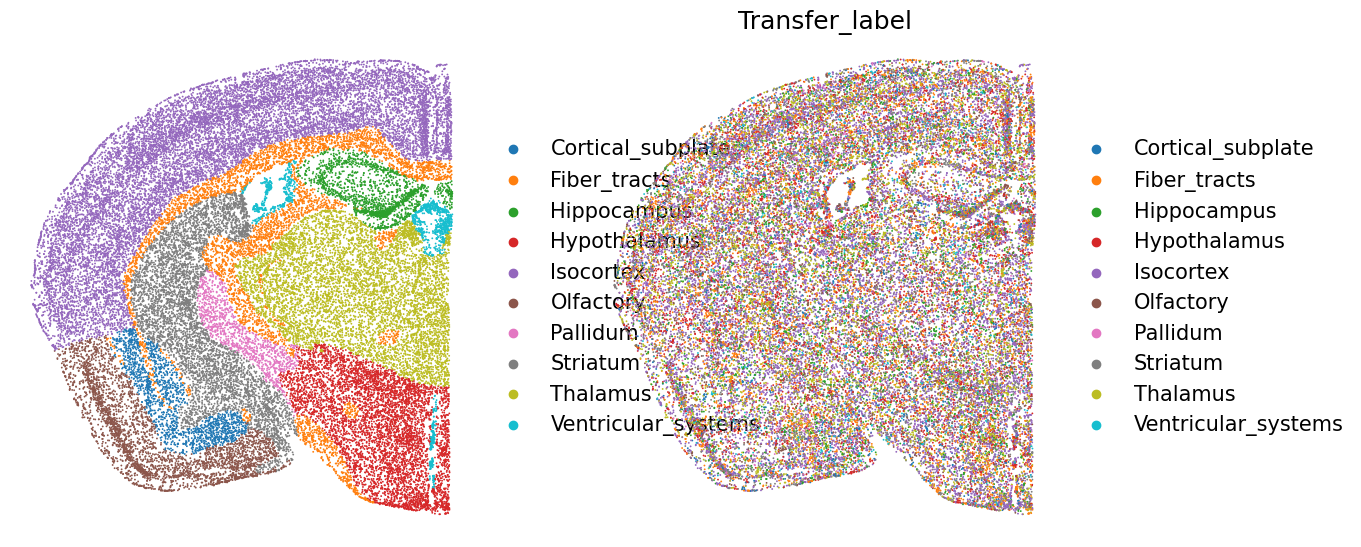

In [24]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1, basis="spatial",s=7,color=['major_brain_region','Transfer_label'],colorbar_loc=None,title='',frameon=False)

In [25]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata1.obs['major_brain_region'])
cluster_labels = np.array(adata1.obs['Transfer_label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.0008747048774264795
NMI: 0.0019050167949020457
AMI: 0.0014382195060871085
FMI: 0.1644041386543855
V-Measure: 0.001905016794902046
Homogeneity: 0.0018972139985878825


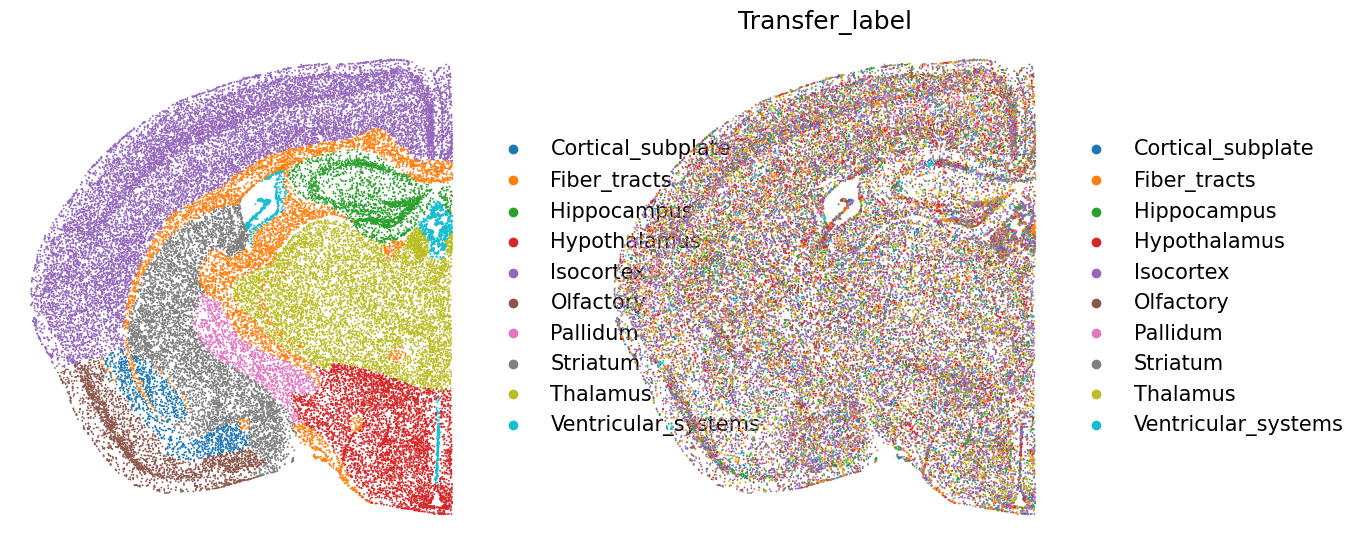

In [26]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata2, basis="spatial",s=7,color=['major_brain_region','Transfer_label'],colorbar_loc=None,title='',frameon=False)

In [27]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata2.obs['major_brain_region'])
cluster_labels = np.array(adata2.obs['Transfer_label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: -0.0022010130300412515
NMI: 0.0020187853191787606
AMI: 0.0015604457156724438
FMI: 0.1667313752843767
V-Measure: 0.00201878531917876
Homogeneity: 0.0020303174542087954
